In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
    ) 
])

In [3]:
DATA_DIR = r'/home/pcdm/Desktop/Rice'
model_algo="alexnet"

In [4]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform,decision_mode=False)

generator = torch.Generator()
generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)
train_size = int(size - valid_size )

trainset, validset = random_split(images, (train_size, valid_size))


In [6]:
valid_size

577

In [7]:
train_size

2309

In [8]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.5213079315183895,train_accu=0.8220008661758337
Epoch=0,valid_loss=0.6373302329144404,valid_accu=0.7677642980935875
0
Epoch=1,train_loss=0.35390350256710534,train_accu=0.8847986141186661
Epoch=1,valid_loss=0.5551895423819742,valid_accu=0.8128249566724437
0
Epoch=2,train_loss=0.23706375443868277,train_accu=0.9246427024686011
Epoch=2,valid_loss=0.484116990603442,valid_accu=0.8405545927209706
0
Epoch=3,train_loss=0.162833254282585,train_accu=0.9449978345604158
Epoch=3,valid_loss=0.4542088227627389,valid_accu=0.8405545927209706
Epoch=4,train_loss=0.1128344623127532,train_accu=0.9662191424859247
Epoch=4,valid_loss=0.43550497696345974,valid_accu=0.8561525129982669
0
Epoch=5,train_loss=0.08773155019958591,train_accu=0.9718492854049372
Epoch=5,valid_loss=0.47118241266320027,valid_accu=0.8648180242634316
0
Epoch=6,train_loss=0.05727974936193046,train_accu=0.9822433954092681
Epoch=6,valid_loss=0.45430565478197565,valid_accu=0.8700173310225303
0
Epoch=7,train_loss=0.0662269922

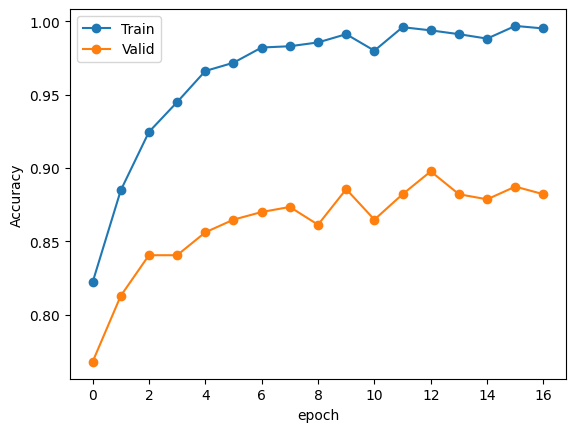

In [9]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_4.pth')

In [10]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.019339250419594407, 0.9956691208315288)

In [11]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.4419065039327281, 0.8925476603119584)

In [12]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [13]:
each_accu=2*p*r/(p+r)
each_accu

Bacterial Leaf Blight     0.988166
Brown Spot                1.000000
Healthy Rice Leaf         0.996610
Leaf Blast                0.993915
Leaf scald                0.994186
Narrow Brown Leaf Spot    0.988593
Neck_Blast                1.000000
Rice Hispa                0.991690
Sheath Blight             0.991597
dtype: float64

In [14]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [15]:
targetF=[x  for x in each_accu.nsmallest(4).index.map(trainset.dataset.classess)]
targetF

[0, 5, 8, 7]

In [16]:
# targetF=[0,3,2,4]

In [17]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(720, 1589)

In [18]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(164, 413)

In [19]:
#decision set
def decision_split(data_dl,model_0):
    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        model_0.eval()   

        for data, target,idx in data_dl:

            data,target=data.to(device),target.to(device)
            out= model_0(data)
            softmax = torch.softmax(out, dim=1)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for i,d,t in zip(idx,data,target):
                # if(t!=0):
                flat_true.append(int(data_dl.dataset.dataset.flag[i]))
                flat_data.append(d.cpu().numpy()) 
            
    return flat_data,flat_true

In [20]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [21]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [85]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None,trainclassnum=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
        model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]
        
    # for param in model.parameters():
    #     param.requires_grad = False

    # for param in model_fc_layer.parameters():
    #     param.requires_grad = True

    if(data_name=="decision"):
        optim = torch.optim.Adam(model.classifier[6].parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        # dense1 = nn.Linear(9216, 224 * 224 * 3)
        # reshape = nn.Unflatten(-1,(3,224, 224))
        # model=nn.Sequential(dense1,reshape,model)
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    # torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model


Epoch=0,train_loss=0.14228623007065602,train_accu=0.9527934170636639
Epoch=0,valid_loss=0.25006138885577617,valid_accu=0.8960138648180243
0
Epoch=1,train_loss=0.08865128542087253,train_accu=0.9770463404071026
Epoch=1,valid_loss=0.2148725686902994,valid_accu=0.9150779896013865
0
Epoch=2,train_loss=0.06553639375373572,train_accu=0.9839757470766566
Epoch=2,valid_loss=0.20355340223782237,valid_accu=0.9185441941074524
0
Epoch=3,train_loss=0.05196018910036298,train_accu=0.9909051537462105
Epoch=3,valid_loss=0.19357690778089734,valid_accu=0.92894280762565
0
Epoch=4,train_loss=0.04254604353952222,train_accu=0.9943698570809875
Epoch=4,valid_loss=0.18529142560742656,valid_accu=0.9324090121317158
0
Epoch=5,train_loss=0.03588398315267369,train_accu=0.9956691208315288
Epoch=5,valid_loss=0.18130384512128772,valid_accu=0.9324090121317158
Epoch=6,train_loss=0.03100714943544748,train_accu=0.9952360329146817
Epoch=6,valid_loss=0.18330028307084467,valid_accu=0.9376083188908145
0
Epoch=7,train_loss=0.0272

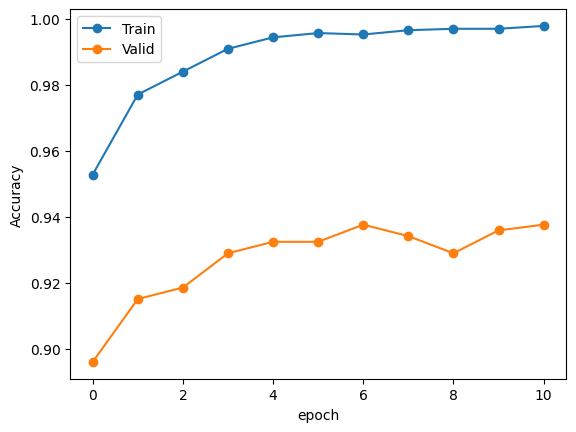

In [86]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

In [24]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.21260697377260712,train_accu=0.9194461925739459
Epoch=0,valid_loss=0.32275451174948466,valid_accu=0.8619854721549637
0
Epoch=1,train_loss=0.12928853136627386,train_accu=0.961611076148521
Epoch=1,valid_loss=0.24815316851866448,valid_accu=0.9031476997578692
0
Epoch=2,train_loss=0.06840260000302338,train_accu=0.9817495280050346
Epoch=2,valid_loss=0.1900394146147998,valid_accu=0.9297820823244553
0
Epoch=3,train_loss=0.052134209209930005,train_accu=0.9811202013845186
Epoch=3,valid_loss=0.22039613243165374,valid_accu=0.9394673123486683
0
Epoch=4,train_loss=0.038651097963269286,train_accu=0.9886721208307111
Epoch=4,valid_loss=0.20751000188976598,valid_accu=0.9322033898305084
Epoch=5,train_loss=0.0227699223929246,train_accu=0.9930774071743235
Epoch=5,valid_loss=0.21792044914519237,valid_accu=0.9467312348668281
0
Epoch=6,train_loss=0.009071211529868702,train_accu=0.9968533668974198
Epoch=6,valid_loss=0.199361140652589,valid_accu=0.9539951573849879
0
Epoch=7,train_loss=0.011

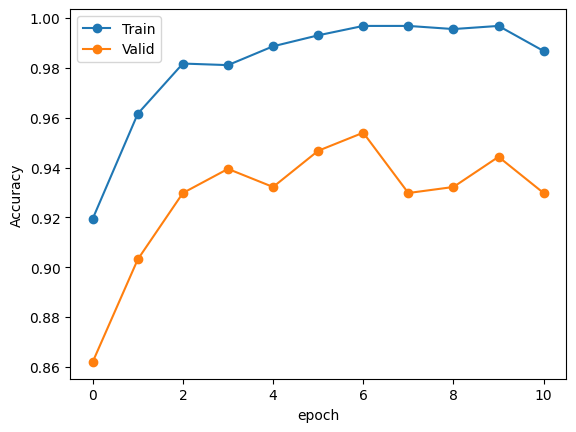

In [25]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

In [26]:
summary(model_T,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 74, 74]          23,296
              ReLU-2           [-1, 64, 74, 74]               0
         MaxPool2d-3           [-1, 64, 36, 36]               0
            Conv2d-4          [-1, 192, 36, 36]         307,392
              ReLU-5          [-1, 192, 36, 36]               0
         MaxPool2d-6          [-1, 192, 17, 17]               0
            Conv2d-7          [-1, 384, 17, 17]         663,936
              ReLU-8          [-1, 384, 17, 17]               0
            Conv2d-9          [-1, 256, 17, 17]         884,992
             ReLU-10          [-1, 256, 17, 17]               0
           Conv2d-11          [-1, 256, 17, 17]         590,080
             ReLU-12          [-1, 256, 17, 17]               0
        MaxPool2d-13            [-1, 256, 8, 8]               0
AdaptiveAvgPool2d-14            [-1, 25

Epoch=0,train_loss=0.505229280392329,train_accu=0.8166666666666667
Epoch=0,valid_loss=0.45562230304973883,valid_accu=0.8475609756097561
0
Epoch=1,train_loss=0.23936854832702212,train_accu=0.9138888888888889
Epoch=1,valid_loss=0.3464265567500417,valid_accu=0.8536585365853658
0
Epoch=2,train_loss=0.15489808205101224,train_accu=0.9541666666666667
Epoch=2,valid_loss=0.2552329000176453,valid_accu=0.9085365853658537
0
Epoch=3,train_loss=0.1605201851990488,train_accu=0.9472222222222222
Epoch=3,valid_loss=0.2680763485955029,valid_accu=0.9024390243902439
Epoch=4,train_loss=0.0643514274723,train_accu=0.9819444444444444
Epoch=4,valid_loss=0.268687400512579,valid_accu=0.8963414634146342
Epoch=5,train_loss=0.0330457246551911,train_accu=0.9888888888888889
Epoch=5,valid_loss=0.23365791977905645,valid_accu=0.9207317073170732
0
Epoch=6,train_loss=0.06339423039721118,train_accu=0.9819444444444444
Epoch=6,valid_loss=0.3874972041060285,valid_accu=0.8658536585365854
Epoch=7,train_loss=0.03600280993721551,t

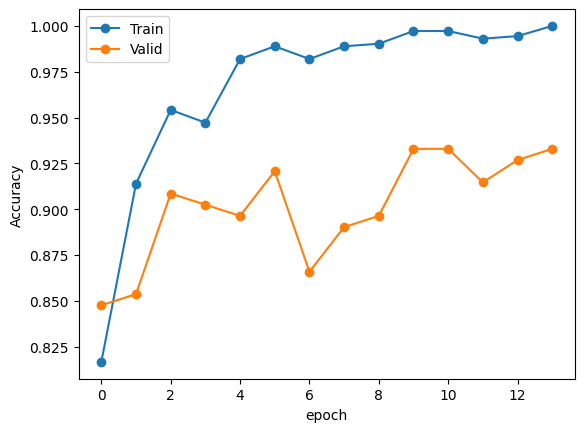

In [27]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [88]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.03100714943544748, 0.9952360329146817)

In [87]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.18330028307084467, 0.9376083188908145)

In [30]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.009481221849999647, 0.9974826935179358)

In [31]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.005804178755109509, 0.9972222222222222)

In [32]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.21079837844749919, 0.9418886198547215)

In [33]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.2611688379178437, 0.9329268292682927)

In [34]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.009216361600843794, 0.9978345604157643, 720)

In [35]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.2031600907883983, 0.9410745233968805, 164)

In [89]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.07008239004775904, 0.9930705933304461, 723, 1586)

In [90]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(1.1241679039723853, 0.8960138648180243, 171, 406)

In [91]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [92]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.019339,0.995669,0.441907,0.892548
1,Model_Decision,0.031007,0.995236,0.183300,0.937608
2,Model_T,0.009481,0.997483,0.210798,0.941889
3,Model_F,0.005804,0.997222,0.261169,0.932927
4,Total_Model,0.070082,0.993071,1.124168,0.896014
5,Total_Model_without_decision,0.009216,0.997835,0.203160,0.941075


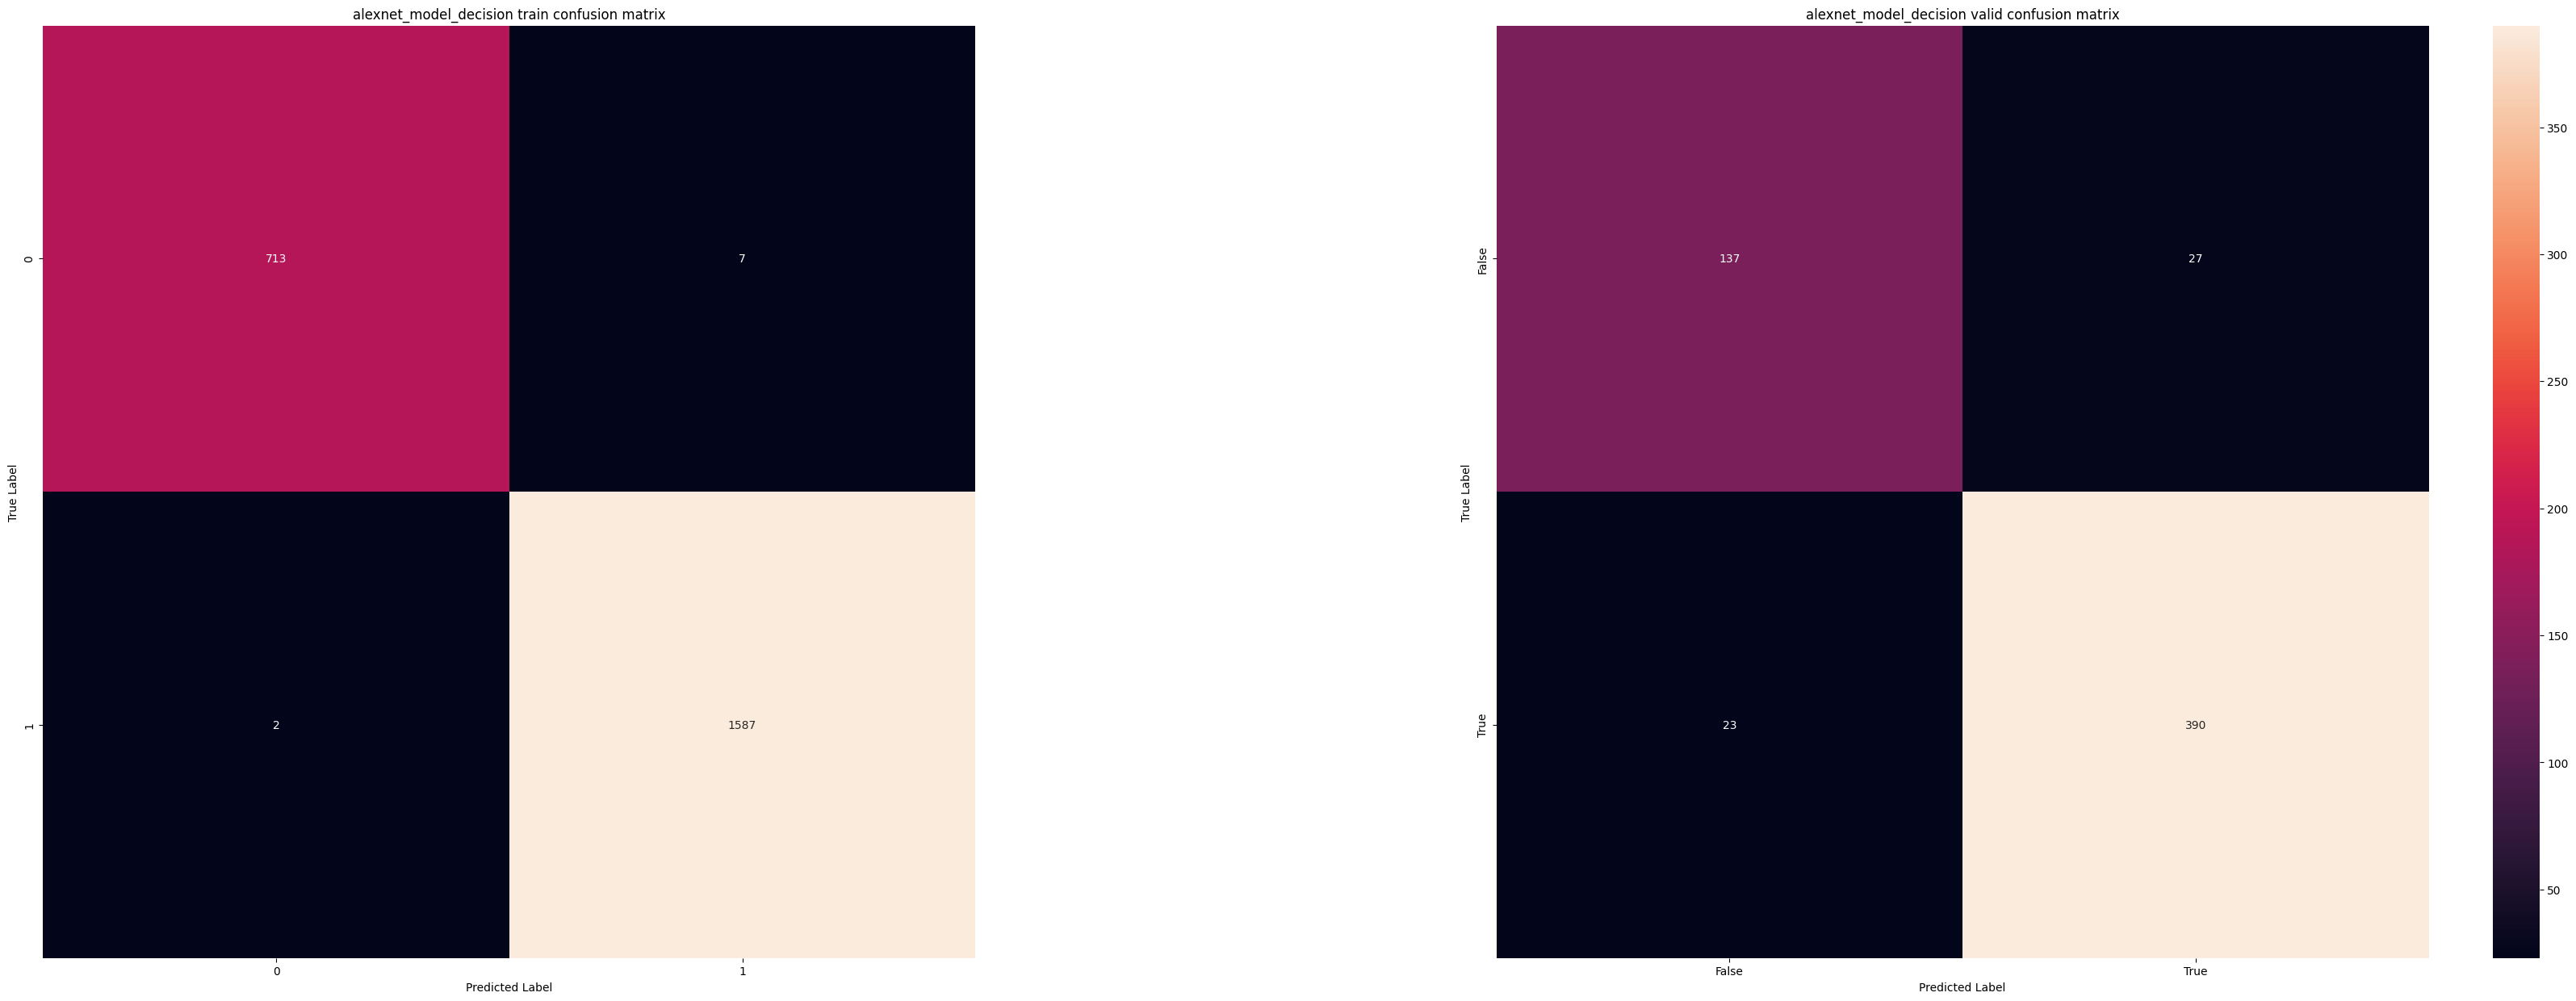

In [40]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

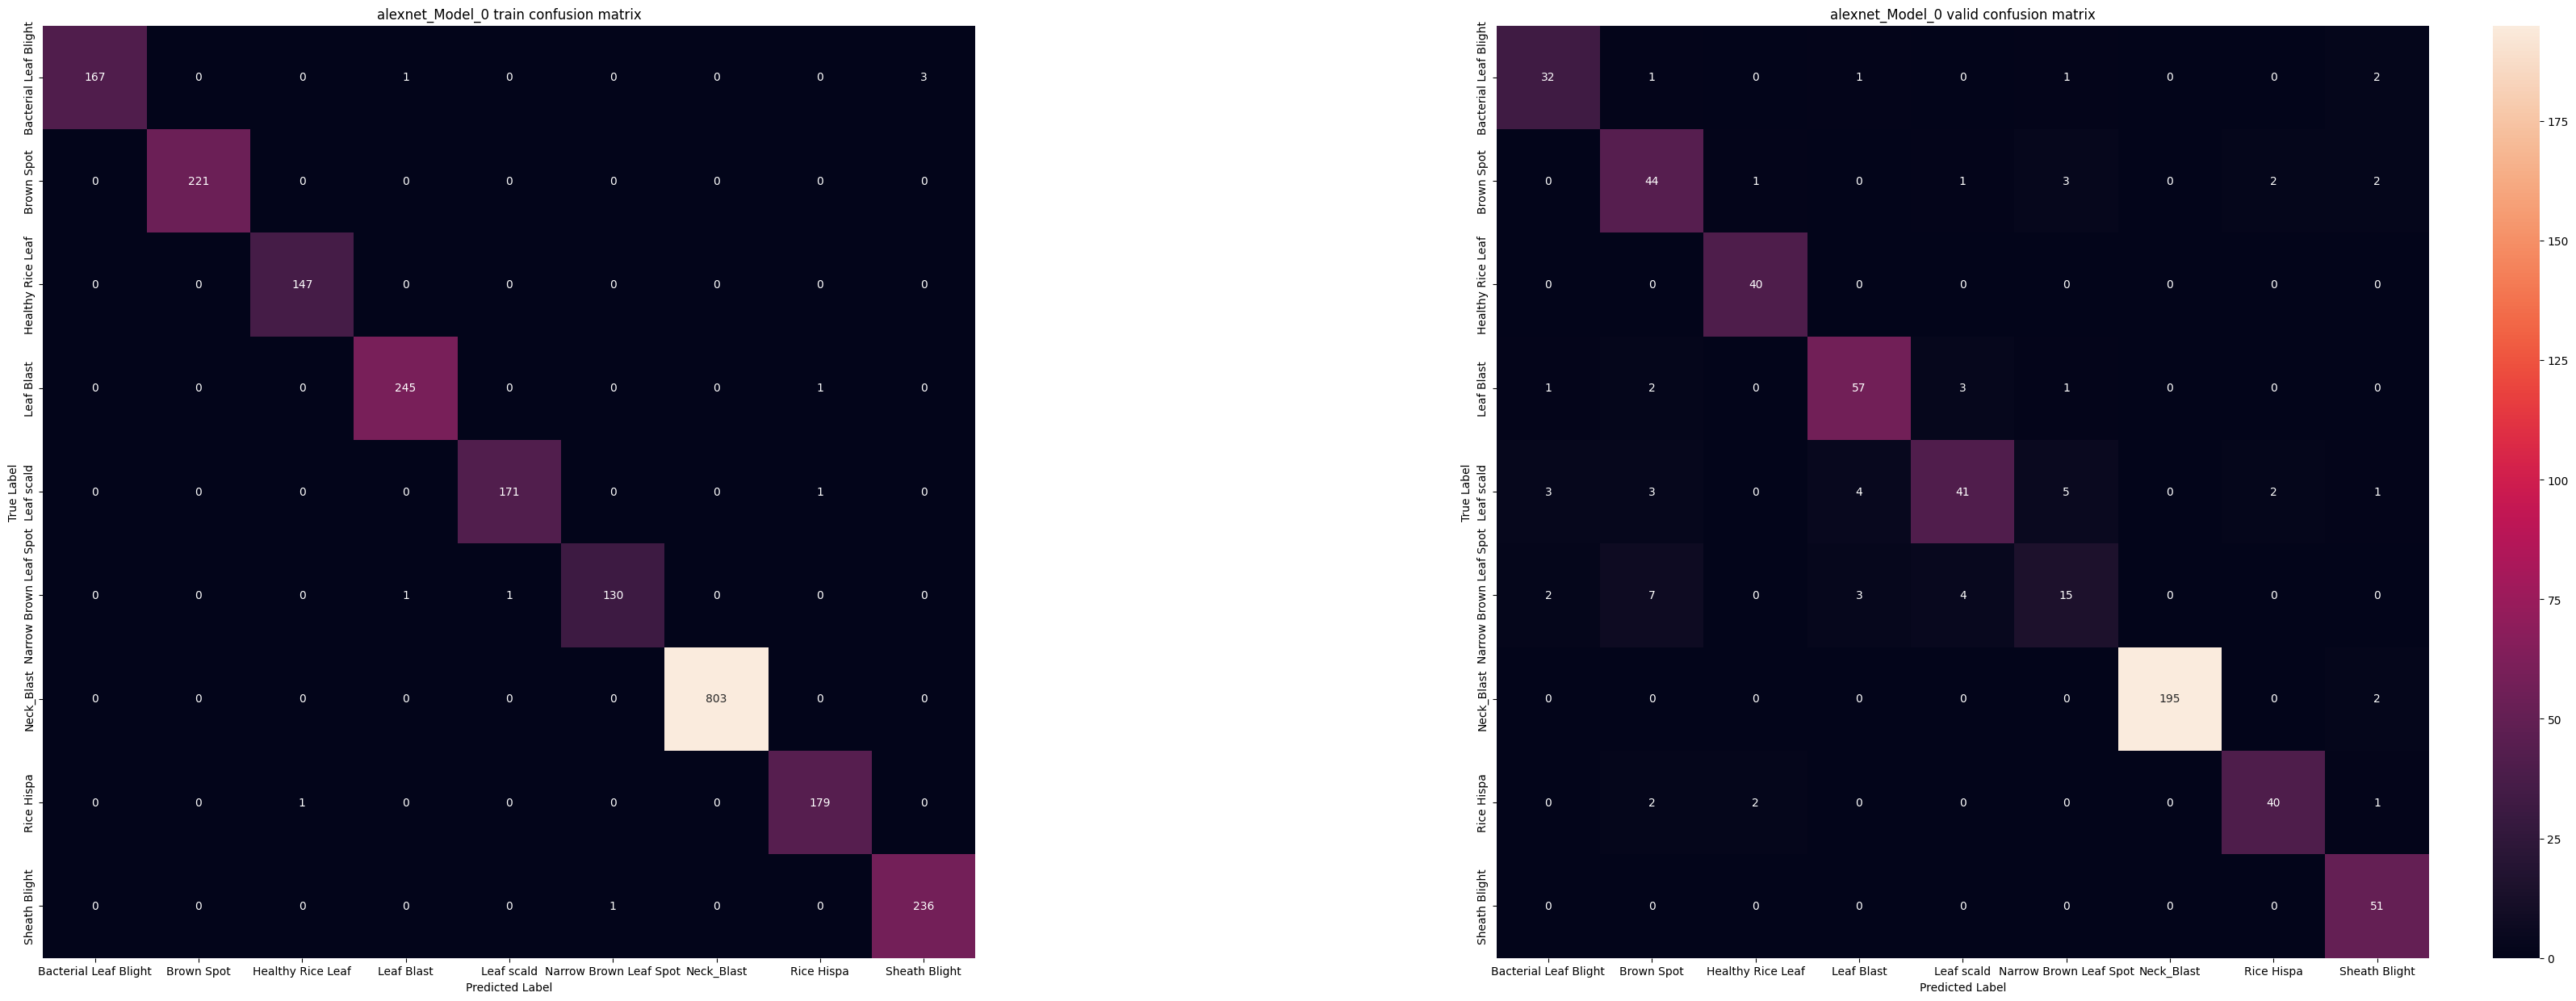

In [41]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

In [42]:
def calculate_confusion(confusion_matrix, N):
    n_classes = confusion_matrix.shape[0]
    confusion_degrees = np.zeros((n_classes, n_classes), dtype=float)
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j:
                degree = (confusion_matrix.iloc[i, j] / np.sum(confusion_matrix.iloc[i])) + \
                        (confusion_matrix.iloc[j, i] / np.sum(confusion_matrix.iloc[j]))
                confusion_degrees[i, j] = degree
    
    # 只检查下三角的元素
    indices = np.tril_indices_from(confusion_degrees, k=-1)
    flat_indices = np.argsort(confusion_degrees[indices])[::-1]
    row_indices = indices[0][flat_indices]
    col_indices = indices[1][flat_indices]
    
    top_elements = confusion_degrees[row_indices, col_indices]
    top_positions = list(zip(row_indices, col_indices))

    print("Top", N, "Elements:")
    print(top_elements[:N])
    print("Top", N, "Positions:")
    print(top_positions[:N])
    
    return top_elements, top_positions

In [43]:
top_elements, top_positions=calculate_confusion(confusion_matrix_valid,N=15)

Top 15 Elements:
[0.28241023 0.21377802 0.11467161 0.11239919 0.09154316 0.08218029
 0.06971538 0.05405405 0.05084746 0.04444444 0.04265203 0.03773585
 0.03389831 0.03125    0.02702703]
Top 15 Positions:
[(5, 1), (5, 4), (4, 3), (5, 3), (5, 0), (7, 1), (4, 1), (8, 0), (4, 0), (7, 2), (3, 0), (8, 1), (7, 4), (3, 1), (1, 0)]


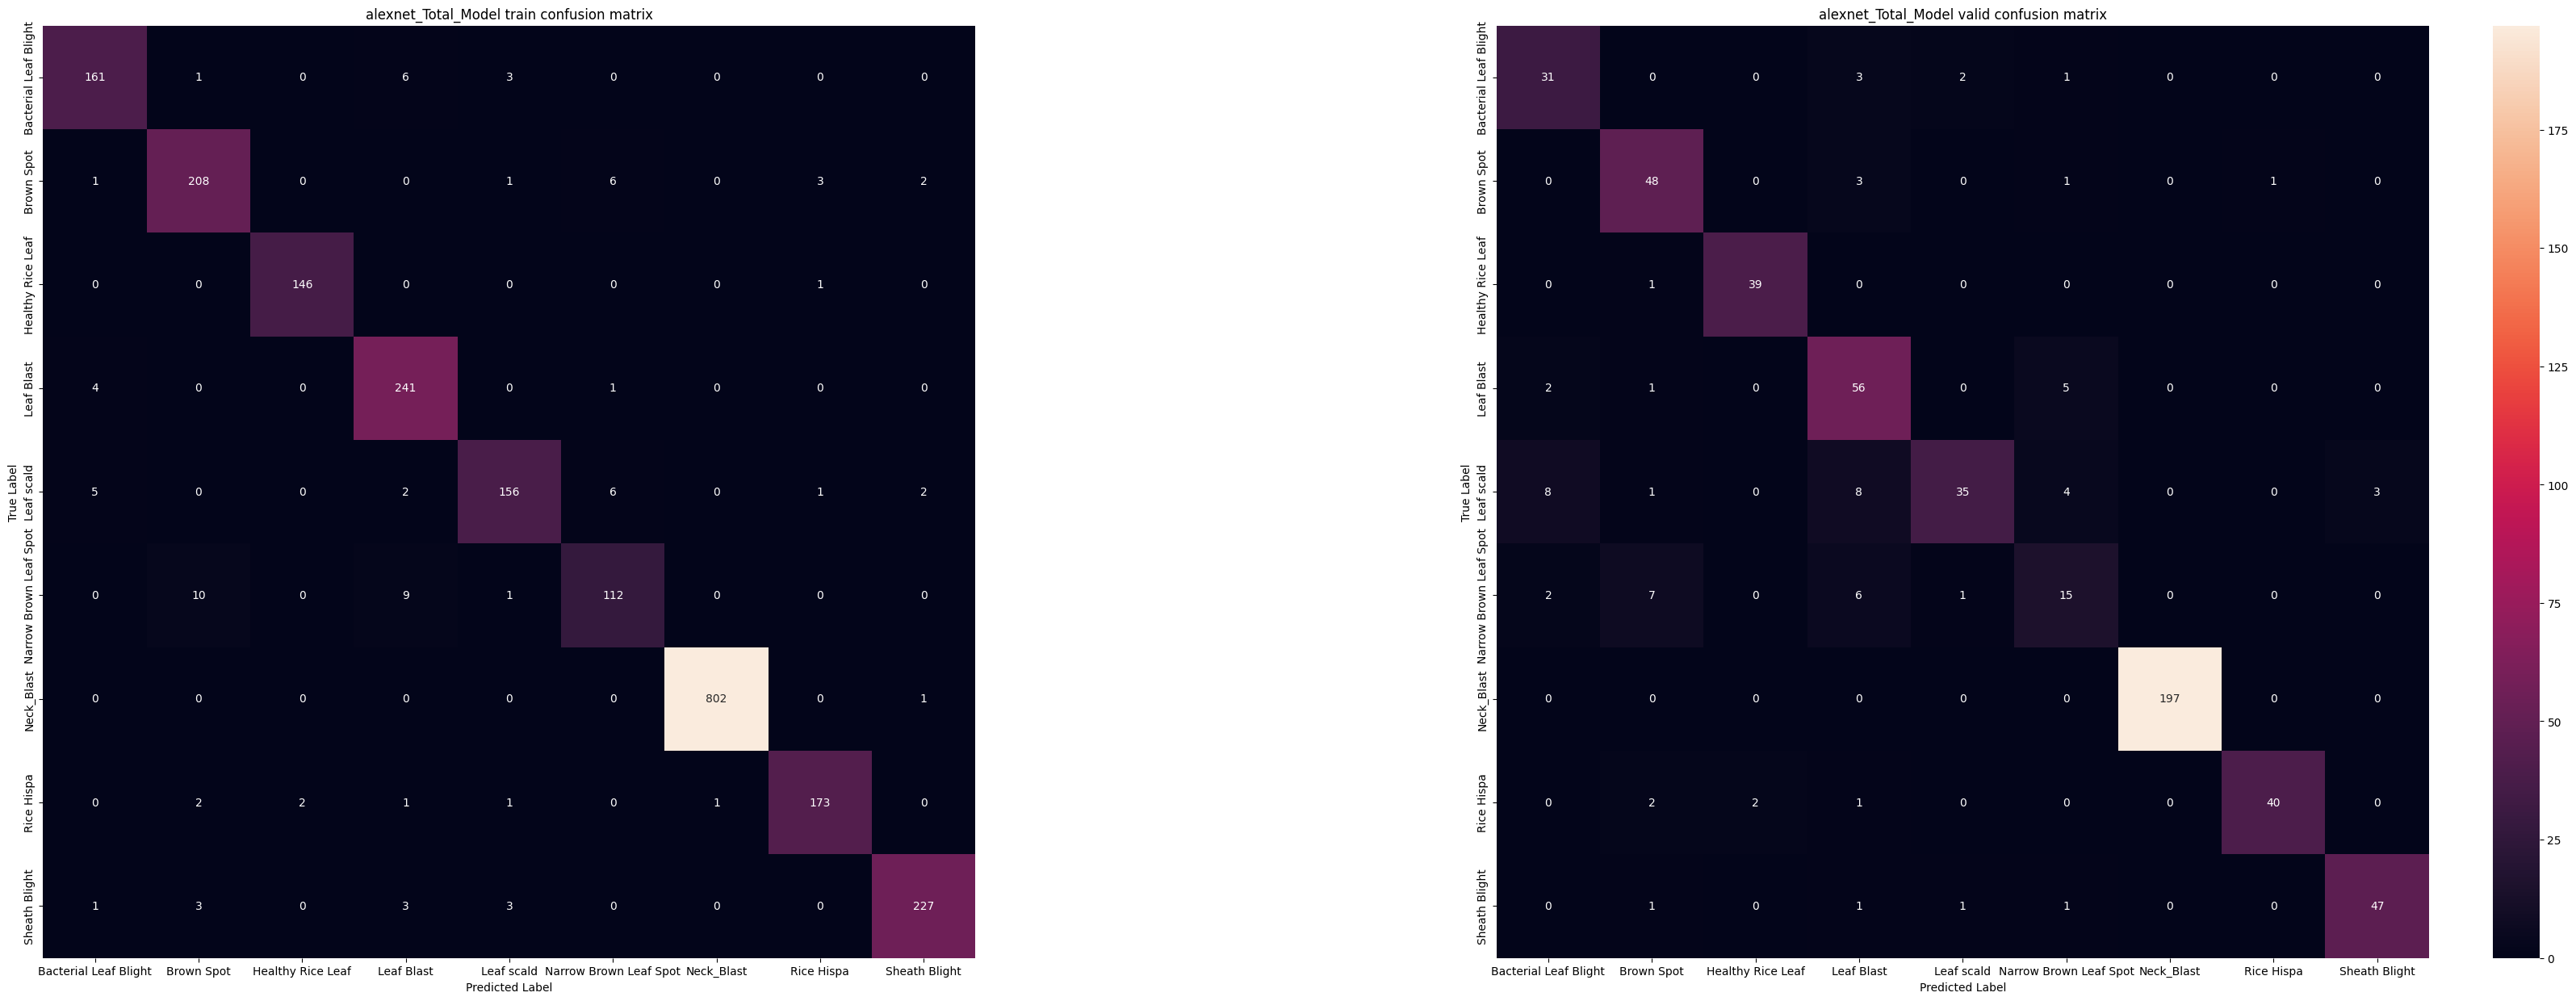

In [44]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

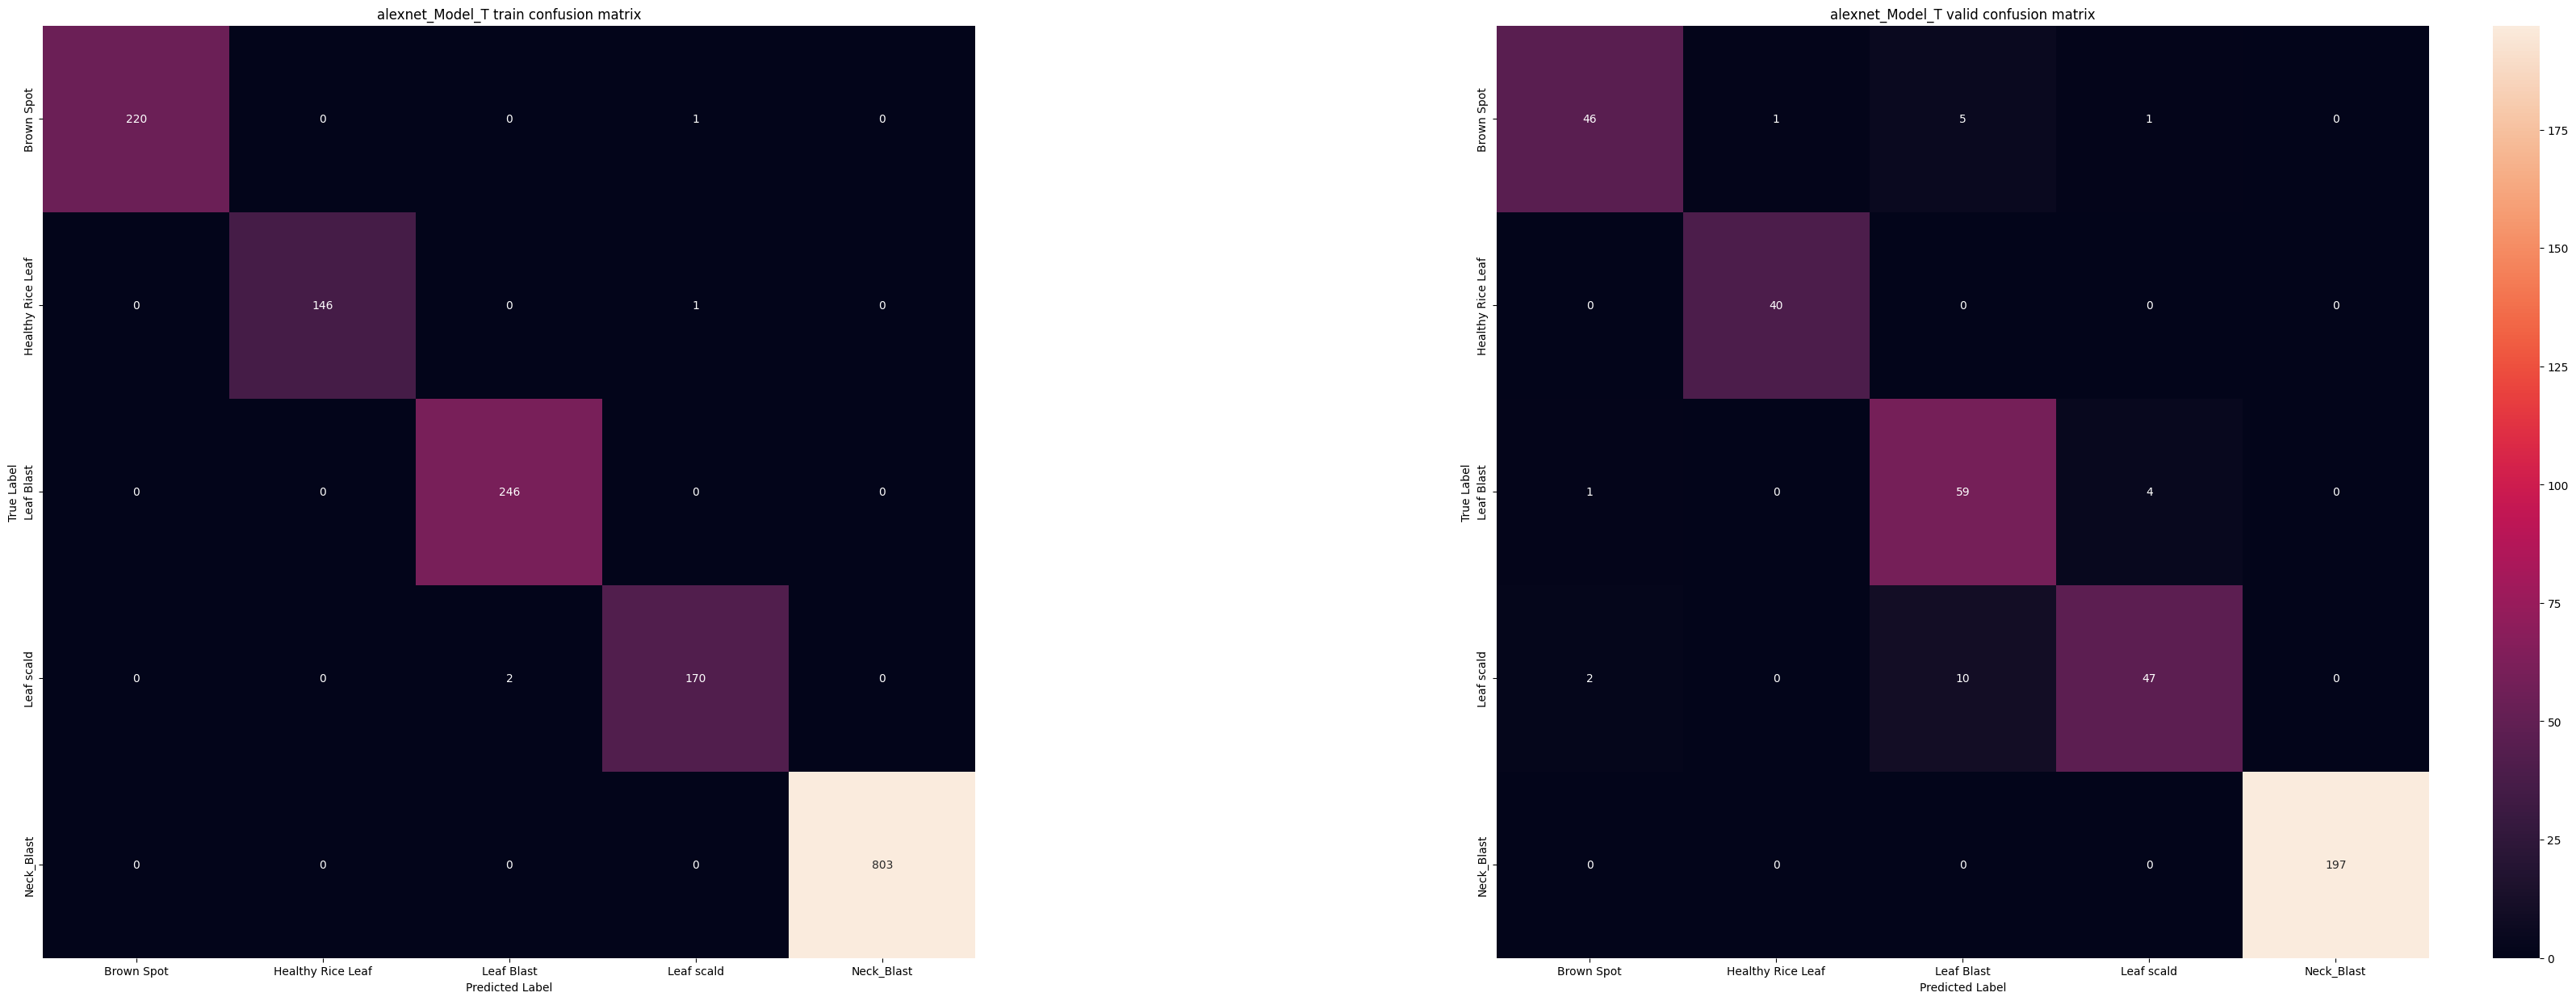

In [45]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

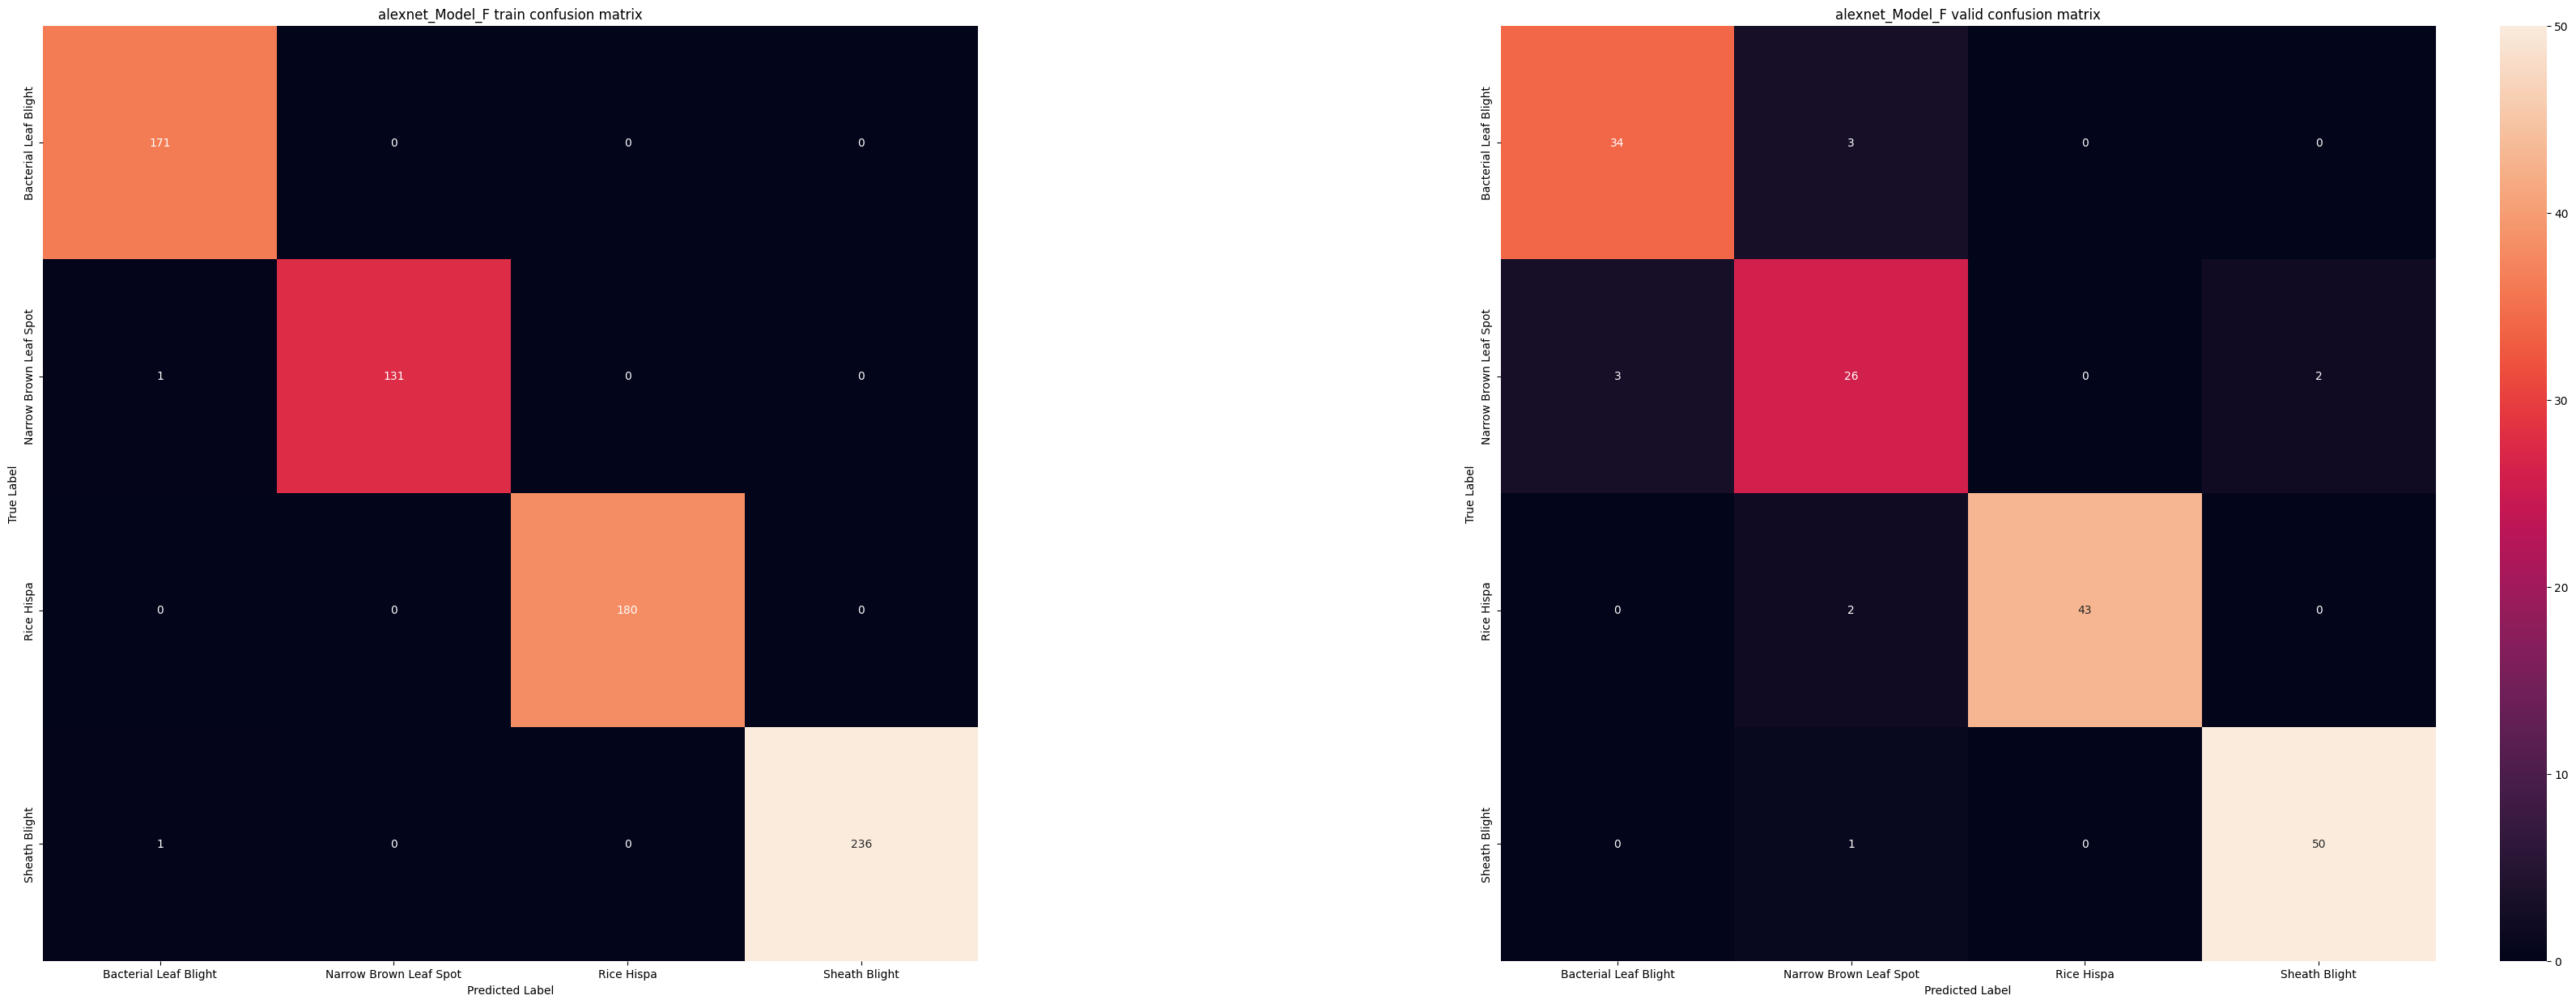

In [46]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [47]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [48]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,2754,8,8,3,8,0.995366,0.652971,0.994609,0.999949,True,False,True,False,False
1,1103,4,5,4,4,0.983975,0.994302,0.999996,0.999850,False,True,True,True,True
2,943,3,5,3,3,0.859151,0.788899,0.999937,1.000000,False,True,True,True,True
3,1648,6,8,6,6,0.999997,1.000000,1.000000,1.000000,False,True,True,True,True
4,1012,4,0,4,4,0.981260,0.999774,0.999986,0.993824,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2304,564,2,7,2,2,0.996214,0.987590,0.999986,0.999945,False,True,True,True,True
2305,2637,8,8,4,8,0.999944,0.999848,0.999518,0.991996,True,False,True,False,False
2306,792,3,5,3,3,0.999926,0.997572,0.999858,0.949581,False,True,True,True,True
2307,293,1,5,1,1,0.782900,0.962820,0.976990,0.964369,False,True,True,True,True


In [49]:
df_results[(df_results['Target']==0)&(df_results['Match_F']!=True)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag


In [50]:
df_results[(df_results['Target']==0)&(df_results['Decision']!=True)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
18,71,0,0,4,0,0.999970,0.994644,0.999547,0.992862,True,False,True,False,False
32,127,0,0,4,0,0.996839,0.932597,0.999854,0.999994,True,False,True,False,False
61,120,0,0,3,0,0.999848,0.801777,0.999814,0.998715,True,False,True,False,False
62,94,0,0,3,0,0.999666,0.896974,0.999985,0.991594,True,False,True,False,False
81,92,0,0,3,0,0.999980,0.981705,0.999500,0.978786,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2196,125,0,0,3,0,0.999442,0.990235,0.999767,0.996376,True,False,True,False,False
2250,57,0,0,4,0,0.999868,0.998286,0.998453,0.941657,True,False,True,False,False
2258,204,0,0,3,0,0.999913,0.536952,0.999473,0.987579,True,False,True,False,False
2269,118,0,0,3,0,0.999992,0.948064,0.999975,0.886512,True,False,True,False,False


In [51]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
17,1192,4,5,4,4,0.618365,0.999843,0.998780,0.867254,False,True,True,False,True
40,2677,8,8,4,8,0.999998,0.950585,0.999973,0.995799,True,False,True,True,False
52,1038,4,0,4,4,0.997419,0.998296,0.999496,0.933687,False,True,True,False,True
86,114,0,0,3,0,1.000000,0.613554,0.999500,0.620579,True,False,True,True,False
171,1037,4,0,4,4,0.999823,0.999607,0.999814,0.940325,False,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,274,1,5,1,1,0.999563,0.999722,0.999999,0.748592,False,True,True,False,True
2241,2806,8,8,4,8,0.998396,0.809011,0.997857,0.871489,True,False,True,True,False
2265,1272,5,5,3,5,0.995783,0.999904,0.999912,0.572872,True,False,True,True,False
2273,1352,5,5,1,5,0.999990,0.999994,0.980185,0.717609,True,False,True,True,False


In [52]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

5    25
0    17
4    16
8    12
1     9
3     6
7     5
2     1
6     1
Name: Target, dtype: int64

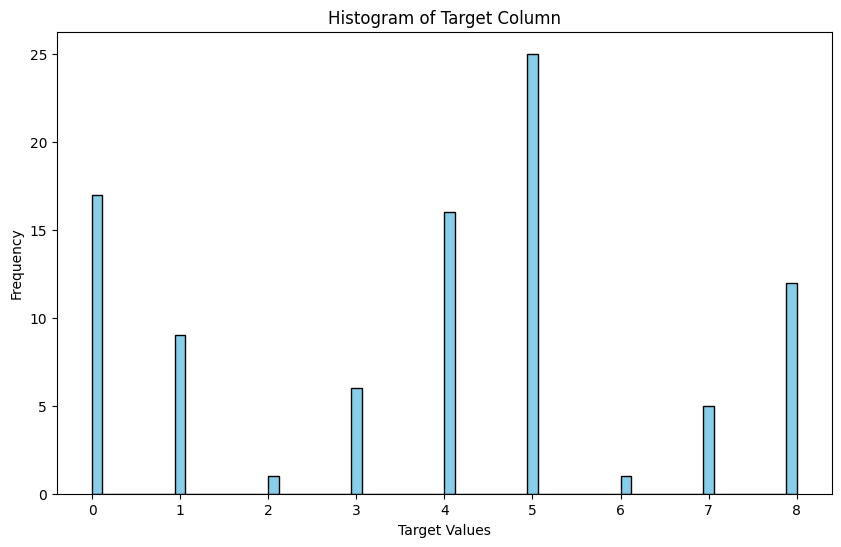

In [53]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [54]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']>df_results['Softmax_T']) & (df_results['flag']==False)])

37

In [55]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']<df_results['Softmax_T']) & (df_results['flag']==True)])

13

In [56]:
df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
17,1192,4,5,4,4,0.618365,0.999843,0.998780,0.867254,False,True,True,False,True
86,114,0,0,3,0,1.000000,0.613554,0.999500,0.620579,True,False,True,True,False
185,2699,8,8,4,8,1.000000,0.999966,0.999997,0.627674,True,False,True,True,False
201,302,1,5,1,1,0.997742,0.998922,0.999824,0.591999,False,True,True,False,True
222,140,0,0,3,0,0.999367,0.759694,0.992503,0.614630,True,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2166,11,0,0,3,0,0.999752,0.998989,0.986268,0.577136,True,False,True,True,False
2187,274,1,5,1,1,0.999563,0.999722,0.999999,0.748592,False,True,True,False,True
2241,2806,8,8,4,8,0.998396,0.809011,0.997857,0.871489,True,False,True,True,False
2265,1272,5,5,3,5,0.995783,0.999904,0.999912,0.572872,True,False,True,True,False


In [57]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,1517,6,8,6,6,1.000000,1.000000,1.000000,1.000000,False,True,True,True,True
1,2593,7,7,4,7,0.998642,0.957824,0.995491,0.998537,True,False,True,False,False
2,1412,6,8,6,6,0.999526,1.000000,1.000000,1.000000,False,True,True,True,True
3,312,1,5,1,2,0.532148,0.562830,0.957016,0.987418,False,True,False,True,True
4,981,4,5,4,4,0.851847,0.964468,0.909864,0.909721,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,1934,6,7,6,6,0.985469,1.000000,0.999995,1.000000,False,True,True,True,True
573,967,3,8,3,3,0.991490,0.999980,0.933258,0.931286,False,True,True,True,True
574,954,3,8,3,3,0.984182,1.000000,1.000000,1.000000,False,True,True,True,True
575,2612,8,8,3,8,0.999317,0.904934,0.997069,0.999827,True,False,True,False,False


In [58]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']>df_results_v['Softmax_T']) & (df_results_v['flag']==False)])

11

In [59]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']<df_results_v['Softmax_T']) & (df_results_v['flag']==True)])

9

In [60]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
11,985,4,5,4,5,0.996491,0.943438,0.836864,0.941695,False,True,False,False,True
17,2750,8,8,1,8,1.000000,0.969286,0.998842,0.961776,True,False,True,True,False
84,1184,4,5,3,0,0.632744,0.620361,0.707741,0.532318,False,False,False,False,True
85,1336,5,0,3,1,0.915272,0.560806,0.521348,0.904571,False,False,False,True,False
90,2817,8,8,3,8,0.998900,0.923008,0.999593,0.834310,True,False,True,True,False
139,1150,4,0,4,4,0.599520,0.999967,0.950656,0.635150,False,True,True,False,True
145,1147,4,5,1,1,0.991043,0.652471,0.587315,0.843768,False,False,False,False,True
164,2541,7,5,1,1,0.985744,0.823182,0.965395,0.993689,False,False,False,True,False
167,750,3,5,3,3,0.996443,0.995467,0.649176,0.918692,False,True,True,False,True
174,1332,5,5,1,1,0.999999,0.999999,0.999953,0.999258,True,False,False,True,False


In [61]:
df_results_v[(df_results_v['Target']==0)&(df_results_v['Match_T']!=True)&(df_results_v['Decision']==True)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
229,20,0,0,3,0,0.998626,0.621383,0.714542,0.501837,True,False,True,True,False
265,44,0,0,4,0,0.999821,0.525353,0.972613,0.774293,True,False,True,True,False
322,2,0,5,4,5,0.968509,0.610980,0.435074,0.514357,False,False,False,True,False
325,16,0,5,3,1,0.936250,0.680607,0.986089,0.868463,False,False,False,True,False
514,141,0,0,3,0,0.878480,0.735475,0.864745,0.868211,True,False,True,True,False
546,115,0,0,4,0,0.999999,0.926091,0.997415,0.820564,True,False,True,True,False


In [62]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

4    14
5    11
3     6
0     6
7     5
8     4
1     3
Name: Target, dtype: int64

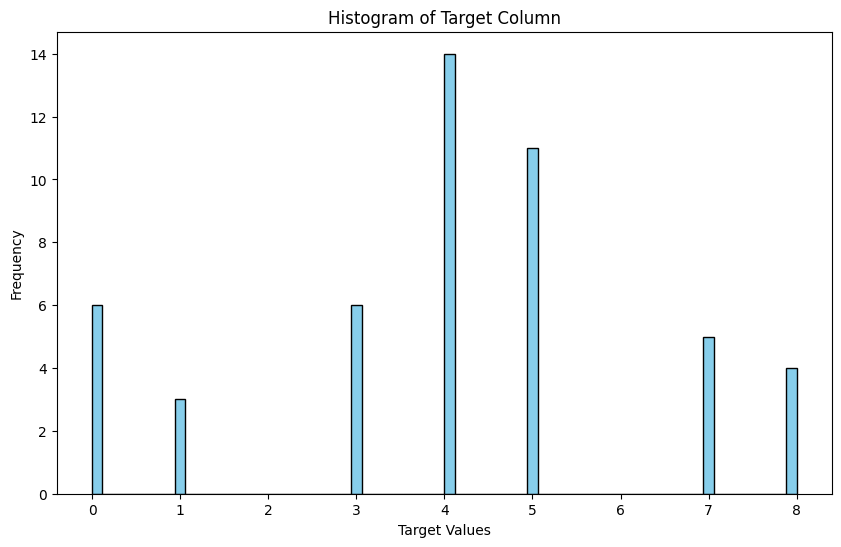

In [63]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [64]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])& (abs(df_results_v['Softmax_F']-df_results_v['Softmax_T'])>0.2)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
85,1336,5,0,3,1,0.915272,0.560806,0.521348,0.904571,False,False,False,True,False
139,1150,4,0,4,4,0.599520,0.999967,0.950656,0.635150,False,True,True,False,True
145,1147,4,5,1,1,0.991043,0.652471,0.587315,0.843768,False,False,False,False,True
180,2782,8,8,3,8,1.000000,0.792432,0.998885,0.999994,True,False,True,True,False
197,1007,4,0,4,4,0.674560,0.964008,0.944047,0.575117,False,True,True,False,True
203,772,3,0,4,4,0.631221,0.925358,0.498858,0.741060,False,False,False,False,True
211,1023,4,5,4,4,0.455391,0.998372,0.987360,0.589986,False,True,True,False,True
229,20,0,0,3,0,0.998626,0.621383,0.714542,0.501837,True,False,True,True,False
265,44,0,0,4,0,0.999821,0.525353,0.972613,0.774293,True,False,True,True,False
288,1172,4,0,4,0,0.995571,0.532720,0.604621,0.895574,False,True,False,False,True


In [65]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
11,985,4,5,4,5,0.996491,0.943438,0.836864,0.941695,False,True,False,False,True
17,2750,8,8,1,8,1.000000,0.969286,0.998842,0.961776,True,False,True,True,False
84,1184,4,5,3,0,0.632744,0.620361,0.707741,0.532318,False,False,False,False,True
85,1336,5,0,3,1,0.915272,0.560806,0.521348,0.904571,False,False,False,True,False
90,2817,8,8,3,8,0.998900,0.923008,0.999593,0.834310,True,False,True,True,False
139,1150,4,0,4,4,0.599520,0.999967,0.950656,0.635150,False,True,True,False,True
145,1147,4,5,1,1,0.991043,0.652471,0.587315,0.843768,False,False,False,False,True
164,2541,7,5,1,1,0.985744,0.823182,0.965395,0.993689,False,False,False,True,False
167,750,3,5,3,3,0.996443,0.995467,0.649176,0.918692,False,True,True,False,True
174,1332,5,5,1,1,0.999999,0.999999,0.999953,0.999258,True,False,False,True,False


In [66]:
# #全部模型裝在一起的表現
# def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
#     total_loss = 0
#     accu = 0
#     flat_true=[]
#     flat_pred=[]
#     sum_F=0
#     sum_T=0
#     with torch.no_grad():
#         for data,target,idx in data_dl:
#             outputs=[]
#             data,target=data.to(device),target.to(device)
#             out_growth = model_0(data)
#             softmax_0=torch.softmax(out_growth, dim=1)

#             out_T = model_T(data)
#             softmax_T=torch.softmax(out_T, dim=1)

#             out_F = model_F(data)
#             softmax_F=torch.softmax(out_F, dim=1)

         
            
#             for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
#                 st_max=torch.max(st).item()
#                 sf_max=torch.max(sf).item()

#                 out_decision=model_decision(d.unsqueeze(0))
#                 _, pred = torch.max(out_decision, dim = 1) 
#                 softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
#                 if(softmax_decision<0.9):
#                     # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
#                     # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
#                     if(sf_max>st_max):
#                         outputs.append(model_F(d.unsqueeze(0)))
#                         sum_F+=1
#                     else:
#                         outputs.append(model_T(d.unsqueeze(0)))
#                         sum_T+=1
#                 else:
                   
#                     if(pred==0):
#                         outputs.append(model_F(d.unsqueeze(0)))
#                         sum_F+=1
#                     else:
#                         outputs.append(model_T(d.unsqueeze(0)))
#                         sum_T+=1

#             outputs = torch.cat(outputs, dim=0)
#             _, y_pred_tag = torch.max(outputs, dim = 1)
#             loss = criterion(outputs, target)


#             flat_true.extend(target.cpu().numpy())
#             flat_pred.extend(y_pred_tag.cpu().numpy())

#             total_loss+= loss.item()*data.size(0)
#             correct=torch.sum(y_pred_tag == target).item()
#             accu += correct      

#     total_loss=total_loss/size
#     accu=accu/size
#     idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
#     confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
#     return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [67]:
#全部模型裝在一起的表現
def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)

         
            
            for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                out_decision=model_decision(d.unsqueeze(0))
                _, pred = torch.max(out_decision, dim = 1) 
                softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
                if(abs(sf_max-st_max)>0.3):
                    # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                    # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
                    if(sf_max>st_max):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                   
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [68]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.555692486324815, 0.9631875270679948, 728, 1581)

In [69]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(1.4325791879894416, 0.8717504332755632, 177, 400)

In [70]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score, f1_score
#模型表現
def evaluate_metric_model(model,data_dl,size,data_name,mode=None):
        
        model.to(device)
        torch.cuda.empty_cache()
        total_loss = 0
        accu = 0
        flat_true=[]
        flat_pred=[]
        with torch.no_grad():
            model.eval()   
            for data, target,idx in data_dl:
                    
                    data,target=data.to(device),target.to(device)
                    out= model(data)
                    _, y_pred_tag = torch.max(out, dim = 1)

                    loss = criterion(out, target)
                    # print(target)
                    flat_true.extend(target.cpu().numpy())
                    flat_pred.extend(y_pred_tag.cpu().numpy())

                    total_loss+= loss.item()*data.size(0)
                    correct=torch.sum(y_pred_tag == target).item()
                    accu += correct      

            total_loss=total_loss/size
            accu=accu/size

        # 计算各种指标
        precision = precision_score(flat_true, flat_pred, average='macro')
        recall = recall_score(flat_true, flat_pred, average='macro')
        f1 = f1_score(flat_true, flat_pred, average='macro')
        

        a=sorted(set(flat_true))
        if(mode=='eval'):
            if(data_name=='decision'):
                confusion_matrix_valid=pd.DataFrame(confusion_matrix(flat_true, flat_pred),columns=list(a),index=list(a))
            else:
                idxtoclass={v:k for k,v in data_dl.dataset.dataset.classes}
                confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred),columns=list(a),index=list(a)).rename(columns=idxtoclass,index=idxtoclass)
            return total_loss,accu,confusion_matrix_valid
        else:
            return total_loss,accu,precision,recall,f1

In [71]:
evaluate_metric_model(model_0,train_dl,train_size,"0",mode=None)

(0.018755819796330037,
 0.996535296665223,
 0.9956052079602825,
 0.9948140656313527,
 0.9951852702160069)

In [72]:
evaluate_metric_model(model_0,valid_dl,valid_size,"0",mode=None)

(0.45944006154087713,
 0.8925476603119584,
 0.8490357776034858,
 0.8502001874778018,
 0.8457121013581433)

In [73]:
evaluate_metric_model(model_0,train_dl,train_size,"0",mode=None)

(0.01931614253517702,
 0.996102208748376,
 0.9950045396542782,
 0.994392537690445,
 0.9946739707459992)